In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
# 1. Задаем путь к папке с вашими файлами. 
# Маска '*.CSV' автоматически найдет все файлы с расширением .csv в этой папке
path_to_files = '/home/no_name/projects/PythonProjects/eco_map/csv_файлов_по_районам' 
all_files = glob.glob(os.path.join(path_to_files, "*.CSV"))

# Создаем пустой список, куда будем складывать очищенные кусочки данных
list_of_dfs = []

# 2. Цикл для обработки каждого файла
for file_path in all_files:
    # Читаем текущий файл
    df = pd.read_csv(file_path)
    
    # --- ЭТАП ПЕРВИЧНОЙ ОБРАБОТКИ ---
    # Удаляем первые 5 строк (используем iloc, чтобы взять строки начиная с 5-й и до конца)
    df_cleaned = df.iloc[5:]
    
    # Сюда же можно добавить ваше удаление выбросов по IQR, если хотите:
    Q1 = df_cleaned['PM1.0'].quantile(0.25)
    Q3 = df_cleaned['PM1.0'].quantile(0.75)
    IQR = Q3 - Q1
    df_cleaned = df_cleaned[(df_cleaned['PM1.0'] >= Q1 - 1.5*IQR) & (df_cleaned['PM1.0'] <= Q3 + 1.5*IQR)]
    
    # Добавляем в DataFrame колонку с именем файла, чтобы вы знали, к какой точке относятся данные
    file_name = os.path.basename(file_path)
    df_cleaned['source_file'] = file_name
    
    # Сохраняем очищенный DataFrame в наш список
    list_of_dfs.append(df_cleaned)

# 3. Склеиваем все файлы из списка в один гигантский DataFrame
final_df = pd.concat(list_of_dfs, ignore_index=True)

# 4. Сохраняем объединенный массив в новый CSV-файл
final_df.to_csv('all_points_combined.csv', index=False)

print(f"Успешно объединено файлов: {len(all_files)}")
print(f"Общее количество строк в итоговом массиве: {len(final_df)}")

Успешно объединено файлов: 38
Общее количество строк в итоговом массиве: 754


Text(0, 0.5, 'PM10')

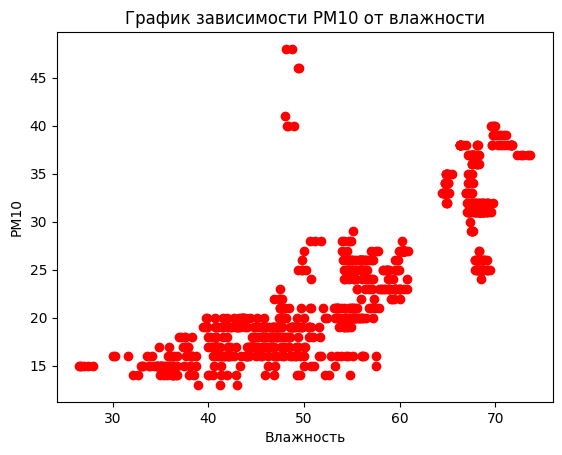

In [ ]:
df = pd.read_csv('all_points_combined.csv')

plt.plot(df['Humidity'], df['PM10'], marker = 'o', linestyle = '', color = 'r' )
plt.title('График зависимости PM10 от влажности')
plt.xlabel('Влажность')
plt.ylabel('PM10')